### **Zero-Shot Noise2Noise: Efficient Image Denoising without any Data**


This repository provides a demonstration of how to use our proposed ZS-N2N (Zero-Shot Noise2Noise) algorithm to denoise images without any training data or a noise model or level as input. The notebook is Pytorch based.

The method is as simple as convolving the noisy image with two fixed kernels to create a pair of downsampled images. A simple 2 layer CNN is then trained with a consistency loss to map one downsampled image to the other.

The notebook can easily be run on GPU or CPU. Choose the device to be 'cuda' if you want to run on GPU, otherwise choose 'cpu'. If you choose 'cuda' remember to change your colab runtime to GPU via 'Runtime' -> 'Change runtime type'.



It is recommended to normalize the pixel range of the images to 0-1, as this is the range the hyperparameters and initialization of the network were tested with.

The network's size was optimized for images of size 256x256. If you have smaller or larger images, you might want to decrease or increase the network's size. This can be done by changing the variable "chan_embed".

The 20 test images from SIDD and PolyU can be found here: https://drive.google.com/file/d/1oJ2wIMPAxK353Shz5kW0Xg-KXmwUwYZR/ .
They are normalized and converted to Pytorch tensors, and can be loaded with torch.load('file_name').

In [2]:
#Enter device here, 'cuda' for GPU, and 'cpu' for CPU
device = 'cuda'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [4]:
# Load test image from URL

import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

# 4 test images from the Kodak24 dataset

#url = "https://drive.google.com/uc?export=download&id=18LcKoV4SYusF16wKqwNBJwYpTXE9myie"
#url = "https://drive.google.com/uc?export=download&id=176lM7ONjvyC83GcllCod-j1RPqjLoRoG"
#url = "https://drive.google.com/uc?export=download&id=1UIh9CwXSCf01JmAXgJo0LPtw5TUkWUU-"
url = "https://drive.google.com/uc?export=download&id=1j1OOzvGhet_GHJCaXbfisiW8uGDxI7ty"

response = requests.get(url)
path=BytesIO(response.content)
#image = Image.open(path)

clean_img = torch.load(path).unsqueeze(0)

print(clean_img.shape) #B C H W

torch.Size([1, 3, 256, 256])


In [ ]:
# McMaster 18 dataset
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms



image_path = './18.tif'
image = Image.open(image_path)


plt.imshow(image)
plt.axis('off')
plt.show()


transform = transforms.ToTensor()
clean_img = transform(image).unsqueeze(0)

print(clean_img.shape)

FileNotFoundError: [Errno 2] No such file or directory: './18.tif'

Add noise to the image

In [20]:
import torchvision.transforms as transforms
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# load Kodak24
PSNR_Total=0
for i in range(1,24):
  image_path = f'./KodaK24/kodim{i}.png'
  image = Image.open(image_path)
  transform = transforms.ToTensor()
  clean_img = transform(image).unsqueeze(0)
  noise_type = 'gauss' # Either 'gauss' or 'poiss'
  noise_level = 25    # Pixel range is 0-255 for Gaussian, and 0-1 for Poission
  noisy_img = add_noise(clean_img, noise_level)
  # add to device
  clean_img = clean_img.to(device)
  noisy_img = noisy_img.to(device)
  ######### mod #################
  max_epoch = 10000     # training epochs
  lr = 0.001           # learning rate
  step_size = 1000     # number of epochs at which learning rate decays
  gamma = 0.5          # factor by which learning rate decays

  optimizer = optim.Adam(model_mod.parameters(), lr=lr)
  scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

  model_mod = Network(n_chan)
  model_mod = model_mod.to(device)

  optimizer = optim.Adam(model_mod.parameters(), lr=lr)
  scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
  with tqdm(range(max_epoch)) as pbar:
      for epoch in pbar:
        train(model_mod, optimizer, noisy_img)
        PSNR = test(model_mod, noisy_img, clean_img)
        scheduler.step()
        pbar.set_postfix({"PSNR": f"{PSNR:.2f}"})

  PSNR_Total+=PSNR
print(f"The avg PSNR : {PSNR_Total/24}")



ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [15]:
noise_type = 'gauss' # Either 'gauss' or 'poiss'
noise_level = 25    # Pixel range is 0-255 for Gaussian, and 0-1 for Poission

def add_noise(x,noise_level):

    if noise_type == 'gauss':
        noisy = x + torch.normal(0, noise_level/255, x.shape) #mu=0

        noisy = torch.clamp(noisy,0,1) #限制0~1


    elif noise_type == 'poiss':
        noisy = torch.poisson(noise_level * x)/noise_level

    return noisy

noisy_img = add_noise(clean_img, noise_level)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [6]:
clean_img = clean_img.to(device)
noisy_img = noisy_img.to(device)
#the shape after conv1torch.Size([1, 48, 128, 128])
#the shape after conv2torch.Size([1, 48, 128, 128])
#the shape after conv3torch.Size([1, 3, 128, 128])

We next define our network, which is a 2 layer CNN

In [ ]:
########## orogin network #####################
class network(nn.Module):
    def __init__(self,n_chan,chan_embed=48): #中間channals數目
        super(network, self).__init__()

        self.act = nn.LeakyReLU(negative_slope=0.2, inplace=True)
        self.conv1 = nn.Conv2d(n_chan,chan_embed,3,padding=1)
        self.conv2 = nn.Conv2d(chan_embed, chan_embed, 3, padding = 1)
        self.conv3 = nn.Conv2d(chan_embed, n_chan, 1)

    def forward(self, x):
        #input #[1,3,128,128]
        x = self.act(self.conv1(x)) #[1, 48, 128, 128]
        #print(f"the shape after conv1{x.shape}")
        x = self.act(self.conv2(x)) # [1, 48, 128, 128]
        #print(f"the shape after conv2{x.shape}")
        x = self.conv3(x) #[1, 3, 128, 128]
        #print(f"the shape after conv3{x.shape}")
        return x

n_chan = clean_img.shape[1]
model_ori = network(n_chan)
model_ori = model_ori.to(device)
print("The number of parameters of the network is: ",  sum(p.numel() for p in model_ori.parameters() if p.requires_grad))

The number of parameters of the network is:  22275


In [ ]:

class MaskedConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, bias=True, use_mask=True):
        super(MaskedConv2d, self).__init__(in_channels, out_channels, kernel_size, stride, padding, dilation, bias=bias)
        self.use_mask = use_mask
        self.mask = self.make_mask(kernel_size)

    def make_mask(self, kernel_size):
        mask = torch.ones(kernel_size, kernel_size)
        mask[kernel_size // 2, kernel_size // 2] = 0
        return mask.view(1, 1, kernel_size, kernel_size)

    def forward(self, x):
        if self.use_mask:
            self.weight.data *= self.mask.to(self.weight.device)
        return F.conv2d(x, self.weight, self.bias, self.stride, self.padding, self.dilation)

class Network(nn.Module):
    def __init__(self, n_chan, chan_embed=48, mask_prob=0.5):
        super(Network, self).__init__()
        self.act = nn.LeakyReLU(negative_slope=0.2, inplace=True)
        self.mask_prob = mask_prob

        # 使用普通的卷積層
        self.conv1 = nn.Conv2d(n_chan, chan_embed, 3, padding=1)
        # 使用掩碼卷積層
        self.conv2 = MaskedConv2d(chan_embed, chan_embed, 3, padding=1, use_mask=True)
        # 最後一層仍然使用普通卷積
        self.conv3 = nn.Conv2d(chan_embed, n_chan, 1)

    def forward(self, x):
        x = self.act(self.conv1(x))  # [1, 48, 128, 128]

        # 在训练过程中随机决定是否应用掩码
        if self.training:  # 只在训练时随机应用掩码
            self.conv2.use_mask = random.random() < self.mask_prob
        else:
            self.conv2.use_mask = False  # 在评估时默认不使用掩码

        x = self.act(self.conv2(x))  # [1, 48, 128, 128] (随机使用或不使用掩码)
        x = self.conv3(x)            # [1, 3, 128, 128]
        return x

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
######### modify #####################
class MaskedConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, bias=True):
        super(MaskedConv2d, self).__init__(in_channels, out_channels, kernel_size, stride, padding, dilation, bias=bias)
        self.mask = self.make_mask(kernel_size)

    def make_mask(self, kernel_size):
        mask = torch.ones(kernel_size, kernel_size)
        mask[kernel_size // 2, kernel_size // 2] = 0
        return mask.view(1, 1, kernel_size, kernel_size)

    def forward(self, x):
        self.weight.data *= self.mask.to(self.weight.device)
        return F.conv2d(x, self.weight, self.bias, self.stride, self.padding, self.dilation)

class Network(nn.Module):
    def __init__(self, n_chan, chan_embed=48):
        super(Network, self).__init__()
        self.act = nn.LeakyReLU(negative_slope=0.2, inplace=True)

        # 使用普通的卷積層
        self.conv1 = nn.Conv2d(n_chan, chan_embed, 3, padding=1)
        # 使用掩碼卷積層
        self.conv2 = MaskedConv2d(chan_embed, chan_embed, 3, padding=1)
        # 最後一層仍然使用普通卷積
        self.conv3 = nn.Conv2d(chan_embed, n_chan, 1)

    def forward(self, x):
        x = self.act(self.conv1(x))  # [1, 48, 128, 128]
        x = self.act(self.conv2(x))  # [1, 48, 128, 128] (使用掩碼卷積)
        x = self.conv3(x)            # [1, 3, 128, 128]
        return x
n_chan = clean_img.shape[1]
model_mod = Network(n_chan)
model_mod = model_mod.to(device)
print("The number of parameters of the network is: ",  sum(p.numel() for p in model_mod.parameters() if p.requires_grad))

The number of parameters of the network is:  22275


We next introduce the image pair downsampler which outputs two downsampled images of half the spatial resolution by averaging diagonal pixels in non-overlapping patches, as shown in the below figure.

It is realised by convolving the image with the 2 fixed kernels: $k_1 = \begin{bmatrix}0 & 0.5 \\0.5 & 0\end{bmatrix}$ and $k_2 = \begin{bmatrix}0.5 & 0 \\0 & 0.5\end{bmatrix}$, where the convolution has stride=2, and is applied to each image channel separately.

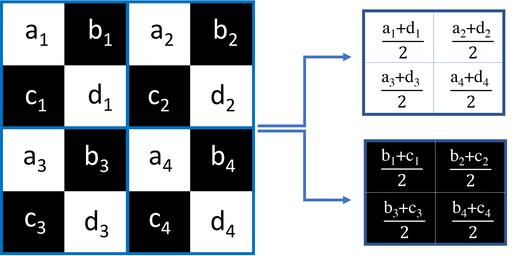

In [9]:
import torch.nn.functional as F
def pair_downsampler(img):
    #img has shape B C H W
    c = img.shape[1] #channal數目

    filter1 = torch.FloatTensor([[[[0 ,0.5],[0.5, 0]]]]).to(img.device)
    filter1 = filter1.repeat(c,1, 1, 1)

    filter2 = torch.FloatTensor([[[[0.5 ,0],[0, 0.5]]]]).to(img.device)
    filter2 = filter2.repeat(c,1, 1, 1)

    output1 = F.conv2d(img, filter1, stride=2, groups=c)
    output2 = F.conv2d(img, filter2, stride=2, groups=c)
    #print(output1.shape)
    #print(output2.shape)
    return output1, output2
def quad_downsampler(img):
    # img has shape B C H W
    c = img.shape[1]  # channel數目

    # 定義四個不同的卷積核，這些卷積核會提取每個2x2區塊中的不同位置
    filter1 = torch.FloatTensor([[[[0.5, 0], [0, 0.5]]]]).to(img.device)
    filter2 = torch.FloatTensor([[[[0, 0.5], [0.5, 0]]]]).to(img.device)
    filter3 = torch.FloatTensor([[[[0.5, 0], [0.5, 0]]]]).to(img.device)
    filter4 = torch.FloatTensor([[[[0, 0.5], [0, 0.5]]]]).to(img.device)

    # 重複每個卷積核到所有通道
    filter1 = filter1.repeat(c, 1, 1, 1)
    filter2 = filter2.repeat(c, 1, 1, 1)
    filter3 = filter3.repeat(c, 1, 1, 1)
    filter4 = filter4.repeat(c, 1, 1, 1)

    # 對每個卷積核進行卷積操作
    output1 = F.conv2d(img, filter1, stride=2, groups=c)
    output2 = F.conv2d(img, filter2, stride=2, groups=c)
    output3 = F.conv2d(img, filter3, stride=2, groups=c)
    output4 = F.conv2d(img, filter4, stride=2, groups=c)

    # 打印形狀以確認輸出形狀是否正確
    # print(output1.shape)
    # print(output2.shape)
    # print(output3.shape)
    # print(output4.shape)

    return output1, output2, output3, output4

def random_subsample(img, stride=2):
    """
    对输入图像进行随机子采样。

    img: 输入图像，形状为 [batch_size, channels, height, width]
    stride: 子采样步长，默认为2。

    返回下采样后的图像。
    """
    batch_size, channels, height, width = img.shape

    # 生成一个随机选择的索引 mask
    mask = np.random.randint(0, stride * stride, (height // stride, width // stride))

    # 初始化输出图像
    subsampled_img = torch.zeros((batch_size, channels, height // stride, width // stride), device=img.device)

    # 对每个网格单元进行随机采样
    for i in range(stride):
        for j in range(stride):
            # 在 mask 中选取需要保留的像素
            selected_pixels = (mask == (i * stride + j))

            # 使用选择的像素创建下采样后的图像
            subsampled_img[:, :, selected_pixels] = img[:, :, i::stride, j::stride][:, :, selected_pixels]
    #print(type(subsampled_img))
    return subsampled_img

def S2B(img):
    # img的形状为 [batch, channels, height, width]
    batch, channels, height, width = img.shape

    # 使用unfold提取每个128x128块
    img_unfold = img.unfold(2, 128, 128).unfold(3, 128, 128)

    # 将展开的块重新排列为新的批次维度
    #print(img_unfold.shape)
    img0 = img_unfold[:, :, 0, 0, :, :].contiguous().view(batch, channels, 128, 128)
    img1 = img_unfold[:, :, 0, 1, :, :].contiguous().view(batch, channels, 128, 128)
    img2 = img_unfold[:, :, 1, 0, :, :].contiguous().view(batch, channels, 128, 128)
    img3 = img_unfold[:, :, 1, 1, :, :].contiguous().view(batch, channels, 128, 128)
    return img0,img1,img2,img3

torch.Size([1, 3, 128, 128])


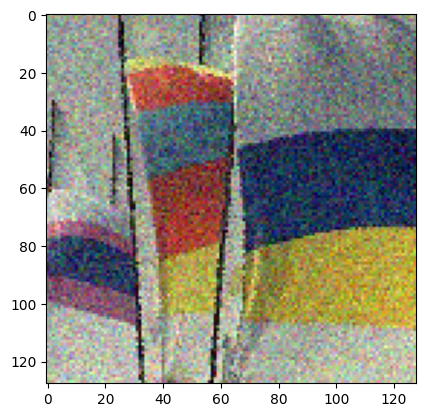

In [ ]:
output = random_subsample(noisy_img, stride=2)
print(output.shape)  # [1,3,128,128]
output_np = output[0].detach().cpu()
plt.imshow(output_np.permute(1,2,0))
plt.show()

torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 128, 128])


Text(0.5, 1.0, 'fourth downsampled')

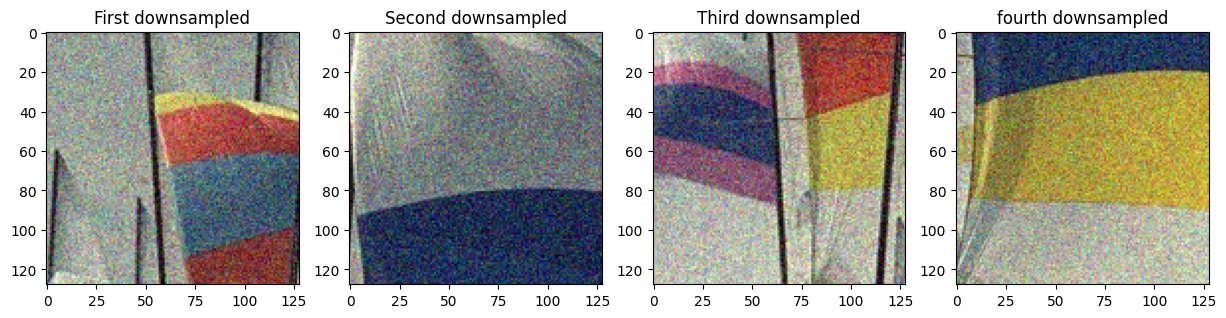

In [ ]:
import matplotlib.pyplot as plt
print(noisy_img.shape)
img0,img1,img2,img3 = S2B(noisy_img) #[B,3,256,256]
print(img1.shape)#[B*64,3,32,32]
fig, ax = plt.subplots(1, 4,figsize=(15, 15))

img0=img0.cpu().squeeze(0).permute(1,2,0)
img1=img1.cpu().squeeze(0).permute(1,2,0)
img2=img2.cpu().squeeze(0).permute(1,2,0)
img3=img3.cpu().squeeze(0).permute(1,2,0)


ax[0].imshow(img0)
ax[0].set_title('First downsampled')

ax[1].imshow(img1)
ax[1].set_title('Second downsampled')

ax[2].imshow(img2)
ax[2].set_title('Third downsampled')

ax[3].imshow(img3)
ax[3].set_title('fourth downsampled')

Display noisy image and its corresponding downsampled pair. Note how the downsampled images have half the spatial resolution.

Text(0.5, 1.0, 'Second downsampled')

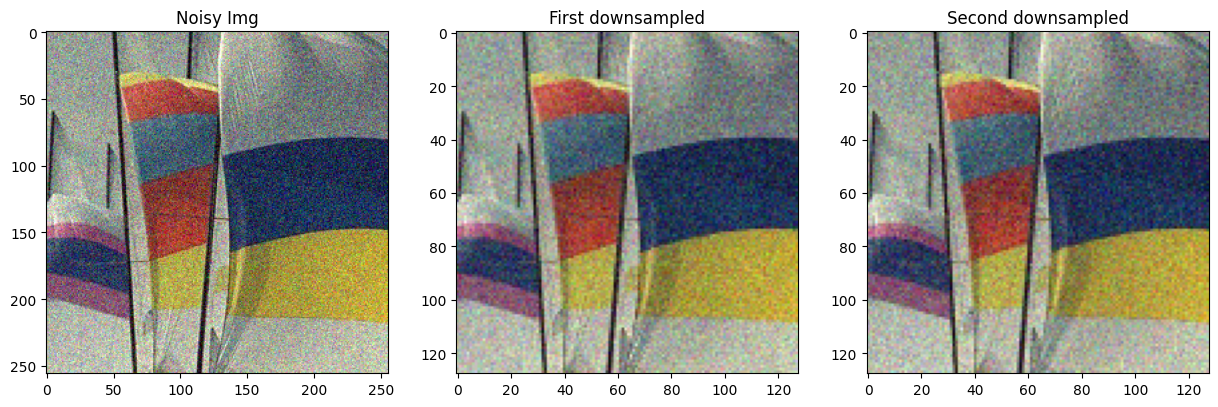

In [ ]:
img1, img2 = pair_downsampler(noisy_img) # [1,3,128,128]

img0 = noisy_img.cpu().squeeze(0).permute(1,2,0) #[256,256,3]
img1 = img1.cpu().squeeze(0).permute(1,2,0)#[128,128,3]
img2 = img2.cpu().squeeze(0).permute(1,2,0)#[128,128,3]

fig, ax = plt.subplots(1, 3,figsize=(15, 15))

ax[0].imshow(img0)
ax[0].set_title('Noisy Img')

ax[1].imshow(img1)
ax[1].set_title('First downsampled')

ax[2].imshow(img2)
ax[2].set_title('Second downsampled')

The loss function is the sum of a residual loss plus a consistency loss as follows:

$$     \mathcal{L}_\mathrm{res.}(\theta) =\frac{1}{2}\left( \|D_1({y}) - f_{\theta}(D_1({y})) - D_2({y})\|_2^2 + \|D_2({y}) - f_{\theta}(D_2({y})) - D_1({y})\|_2^2 \right). $$

$$     \mathcal{L}_\mathrm{cons.}(\theta) = \frac{1}{2} \left( \|f_{\theta}(D_1({y})) - D_1(f_{\theta}({y}))\|_2^2 + \|f_{\theta}(D_2({y})) - D_2(f_{\theta}({y}))\|_2^2 \right). $$

$$ \mathcal{L}(\theta) = \mathcal{L}_\mathrm{res.}(\theta) + \mathcal{L}_\mathrm{cons.}(\theta), $$

where $y$ is the noisy input image, $D$ is the image pair downsampler, and $f_\theta$ is the network.


In [10]:
def mse(gt: torch.Tensor, pred:torch.Tensor)-> torch.Tensor: #應該返回Tensor
    loss = torch.nn.MSELoss()
    return loss(gt,pred)

def loss_func(model,noisy_img):
  ######### 先downSampler 再 denoise####################
    noisy1, noisy2 = pair_downsampler(noisy_img)

    pred1 =  noisy1 - model(noisy1)
    pred2 =  noisy2 - model(noisy2)

    loss_res = 1/2*(mse(noisy1,pred2)+mse(noisy2,pred1)) #圖1 與去躁後的圖二 + 圖二與去躁後的圖一



    #只使用res 會overfitting
###############先 denoise 再 downsampler #######################
    #所以提出一致性損失
    noisy_denoised =  noisy_img - model(noisy_img) #先denoise
    denoised1, denoised2 = pair_downsampler(noisy_denoised)

    loss_cons=1/2*(mse(pred1,denoised1) + mse(pred2,denoised2))

    loss = loss_res + loss_cons

    ############## new #####################
    '''
    #return loss

    noisy1=random_subsample(noisy_img)
    noisy2=random_subsample(noisy_img)

    pred1 =  noisy1 - model(noisy1)
    pred2 =  noisy2 - model(noisy2)

    loss_new = 1/2*(mse(noisy1,pred2)+mse(noisy2,pred1)) #圖1 與去躁後的圖二 + 圖二與去躁後的圖一
    #loss = loss_res + loss_cons + loss_new
    '''
    ########################## try quad     ######################
    # 示例使用
    '''
    noisy1, noisy2, noisy3, noisy4 = quad_downsampler(noisy_img)

    # 使用模型進行去噪預測
    pred1 = noisy1 - model(noisy1)
    pred2 = noisy2 - model(noisy2)
    pred3 = noisy3 - model(noisy3)
    pred4 = noisy4 - model(noisy4)

    # 計算損失，使用每個區塊與其他區塊去噪後結果的損失
    loss_quad = (1/4) * (
        mse(noisy1, pred2) + mse(noisy1, pred3) + mse(noisy1, pred4) +
        mse(noisy2, pred1) + mse(noisy2, pred3) + mse(noisy2, pred4) +
        mse(noisy3, pred1) + mse(noisy3, pred2) + mse(noisy3, pred4) +
        mse(noisy4, pred1) + mse(noisy4, pred2) + mse(noisy4, pred3)
    )

    '''

    ############### S2B ##################
    '''
    noisy1, noisy2, noisy3, noisy4 = S2B(noisy_img)
    pred1 = noisy1 - model(noisy1)
    pred2 = noisy2 - model(noisy2)
    pred3 = noisy3 - model(noisy3)
    pred4 = noisy4 - model(noisy4)


    # 計算損失，使用每個區塊與其他區塊去噪後結果的損失

    loss_quad = (1/4) * (
        mse(noisy1, pred2) + mse(noisy1, pred3) + mse(noisy1, pred4) +
        mse(noisy2, pred1) + mse(noisy2, pred3) + mse(noisy2, pred4) +
        mse(noisy3, pred1) + mse(noisy3, pred2) + mse(noisy3, pred4) +
        mse(noisy4, pred1) + mse(noisy4, pred2) + mse(noisy4, pred3)
    )
    loss = loss = loss_res + loss_cons + loss_quad
    '''
    return loss


Train, test, and denoise functions

In [11]:
def train(model, optimizer, noisy_img):

  loss = loss_func(model,noisy_img)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  return loss.item()

def test(model, noisy_img, clean_img):

    with torch.no_grad():
        pred = torch.clamp(noisy_img - model(noisy_img),0,1)
        MSE = mse(clean_img, pred).item()
        PSNR = 10*np.log10(1/MSE)

    return PSNR

def denoise(model, noisy_img):

    with torch.no_grad():
        pred = torch.clamp( noisy_img - model(noisy_img),0,1)

    return pred

Optimizer and Hyperparameters

In [13]:
import random
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
set_seed(0)

In [ ]:
max_epoch = 10000     # training epochs
lr = 0.001           # learning rate
step_size = 1000     # number of epochs at which learning rate decays
gamma = 0.5          # factor by which learning rate decays

optimizer = optim.Adam(model_mod.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

Start denoising

In [ ]:
######### mod #################
optimizer = optim.Adam(model_mod.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
max_epoch = 10000     # training epochs
lr = 0.001           # learning rate
step_size = 1000     # number of epochs at which learning rate decays
gamma = 0.5          # factor by which learning rate decays

model_mod = Network(n_chan)
model_mod = model_mod.to(device)

optimizer = optim.Adam(model_mod.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
with tqdm(range(max_epoch)) as pbar:
    for epoch in pbar:
      train(model_mod, optimizer, noisy_img)
      PSNR = test(model_mod, noisy_img, clean_img)
      scheduler.step()
      pbar.set_postfix({"PSNR": f"{PSNR:.2f}"})

  0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
############ model origin ####################
import sys
max_epoch = 10000     # training epochs
lr = 0.001           # learning rate
step_size = 1000     # number of epochs at which learning rate decays
gamma = 0.5          # factor by which learning rate decays

model_ori = Network(n_chan)
model_ori = model_ori.to(device)

optimizer = optim.Adam(model_ori.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
with tqdm(range(max_epoch)) as pbar:
    for epoch in pbar:
      train(model_ori, optimizer, noisy_img)
      PSNR = test(model_ori, noisy_img, clean_img)
      if PSNR>29:
        sys.exit()
      scheduler.step()
      pbar.set_postfix({"PSNR": f"{PSNR:.2f}"})

  0%|          | 0/10000 [00:00<?, ?it/s]

SystemExit: 

PSNR of denoised image

origin29.012535946102354,modify31.517030659708077


[Text(0.5, 0, '31.52 dB')]

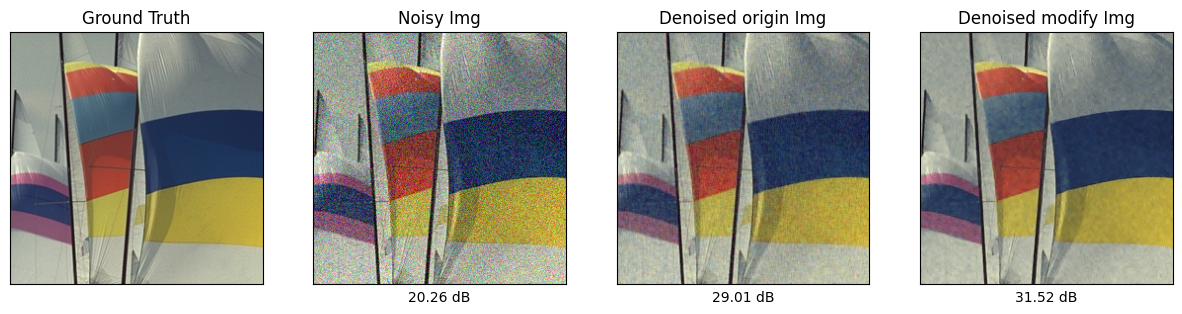

In [ ]:
PSNR_ori = test(model_ori, noisy_img, clean_img)
PSNR_mod = test(model_mod, noisy_img, clean_img)
print(f"origin{PSNR_ori},modify{PSNR_mod}")
#############
denoised_ori_img = denoise(model_ori, noisy_img)
denoised_mod_img = denoise(model_mod, noisy_img)

denoised_ori = denoised_ori_img.cpu().squeeze(0).permute(1,2,0) #變成(H,C,W)
denoised_mod = denoised_mod_img.cpu().squeeze(0).permute(1,2,0) #變成(H,C,W)
clean = clean_img.cpu().squeeze(0).permute(1,2,0)
noisy = noisy_img.cpu().squeeze(0).permute(1,2,0)
########### #################################
fig, ax = plt.subplots(1, 4,figsize=(15, 15))

ax[0].imshow(clean)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Ground Truth')

ax[1].imshow(noisy)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Noisy Img')
noisy_psnr = 10*np.log10(1/mse(noisy_img,clean_img).item())
ax[1].set(xlabel= str(round(noisy_psnr,2)) + ' dB')

ax[2].imshow(denoised_ori)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Denoised origin Img')
ax[2].set(xlabel= str(round(PSNR_ori,2)) + ' dB')


ax[3].imshow(denoised_mod)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Denoised modify Img')
ax[3].set(xlabel= str(round(PSNR_mod,2)) + ' dB')

In [ ]:
#29.19 if add RS
# 31.566 origin
# 使用掩碼 沒什麼差別
# 用掩碼+原本 31.28
# 原本 31.21
# quad sampler 爛死

PSNR = test(model, noisy_img, clean_img)
print(PSNR)

15.729580840202367


Display clean, noisy, and denoised images.

In [ ]:
denoised_img = denoise(model, noisy_img)

denoised = denoised_img.cpu().squeeze(0).permute(1,2,0) #變成(H,C,W)
clean = clean_img.cpu().squeeze(0).permute(1,2,0)
noisy = noisy_img.cpu().squeeze(0).permute(1,2,0)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1, 3, 256, 256])) that is different to the input size (torch.Size([1, 3, 500, 500])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (500) must match the size of tensor b (256) at non-singleton dimension 3

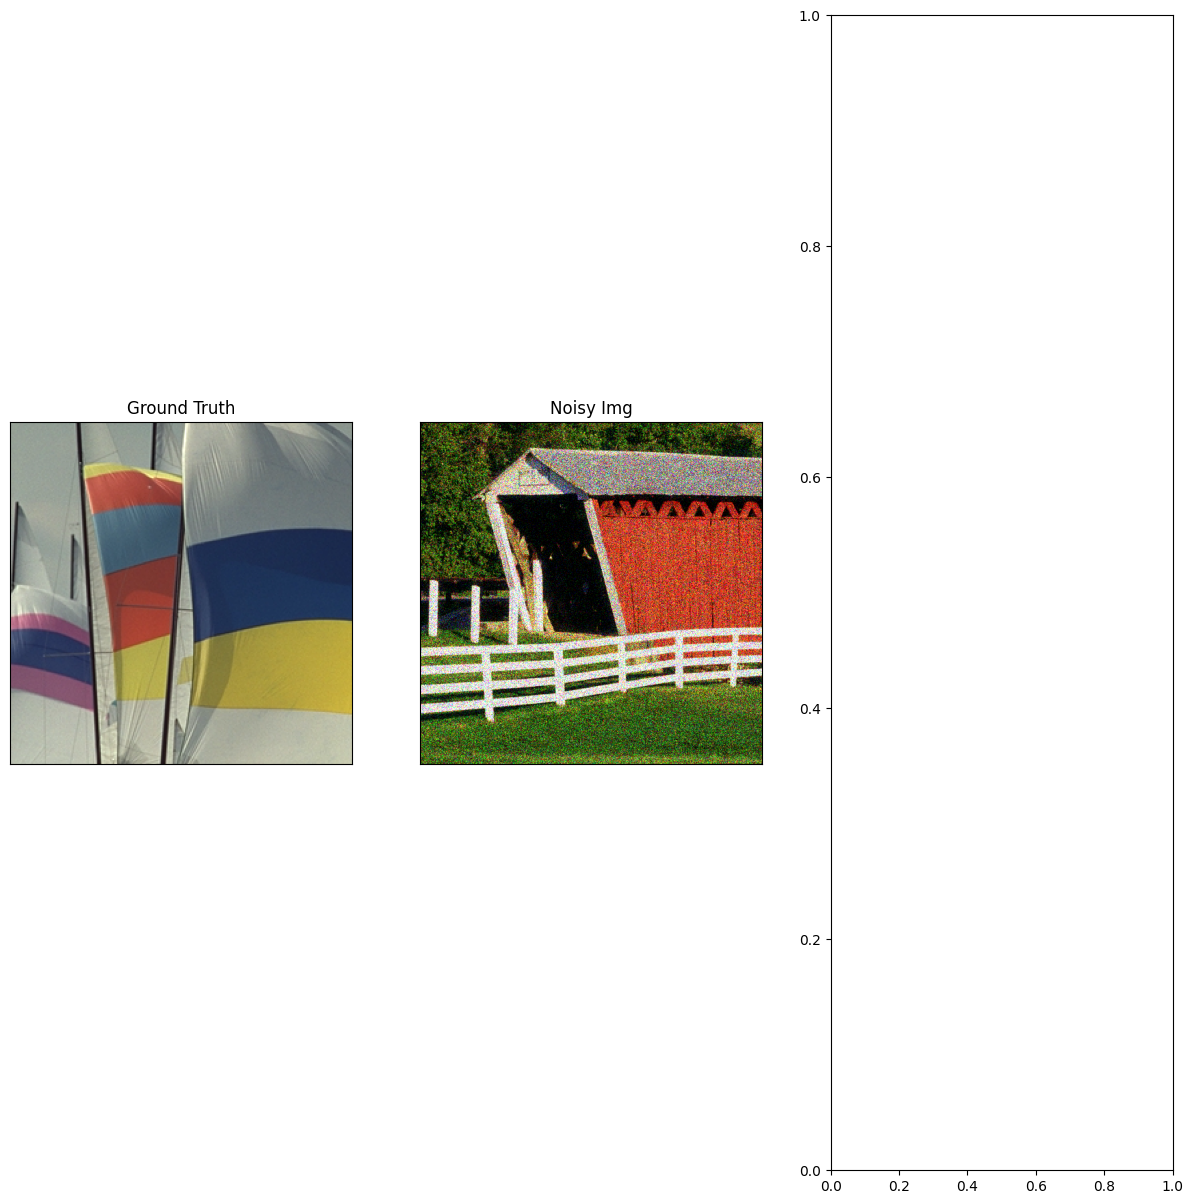

In [ ]:
fig, ax = plt.subplots(1, 3,figsize=(15, 15))

ax[0].imshow(clean)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Ground Truth')

ax[1].imshow(noisy)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Noisy Img')
noisy_psnr = 10*np.log10(1/mse(noisy_img,clean_img).item())
ax[1].set(xlabel= str(round(noisy_psnr,2)) + ' dB')

ax[2].imshow(denoised)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Denoised Img')
ax[2].set(xlabel= str(round(PSNR,2)) + ' dB')